# ARRGO: Experimental Evaluation

This notebook evaluates the empirical behavior of ARRGO on a collection of deterministic benchmark functions.

The purpose of the experimental evaluation is to examine whether the implemented algorithm behaves consistently with the theoretical and algorithmic design established in the previous notebooks.

The experiments focus on:

- optimization behavior;
- convergence of the best observed objective value;
- spatial refinement of the search domain;
- balance between sampling and splitting;
- behavior of the region hierarchy;
- numerical robustness;
- empirical versus certified execution;
- consistency across different objective landscapes.

The experiments are intended to validate the observed behavior of ARRGO rather than to establish a universal proof of global optimality.

All conclusions are therefore interpreted within the assumptions and limitations established in the theoretical foundations and implementation design.

## 1. Experimental Objectives

The experimental evaluation is designed to answer a set of concrete questions about the behavior of ARRGO.

### Objective 1: Optimization Behavior

Determine whether ARRGO can progressively improve the best observed objective value while refining the search domain.

The primary quantity is:

$$
f_{\mathrm{best}}^{(t)}
=
\max_{1 \leq i \leq N_t} f(x_i),
$$

where \(N_t\) is the number of objective evaluations available at iteration \(t\).

Because ARRGO is formulated as a maximization framework, an improvement in the incumbent corresponds to an increase in \(f_{\mathrm{best}}\).

### Objective 2: Spatial Refinement

Examine how ARRGO allocates refinement effort across the search domain.

The experiments track:

- region widths;
- region hierarchy depth;
- active regions;
- refined regions;
- sampling locations;
- split locations.

This allows the spatial behavior of the adaptive refinement mechanism to be observed directly.

### Objective 3: Sampling and Splitting Behavior

Evaluate how ARRGO balances the two principal refinement mechanisms:

- **Sampling**, which increases information about the objective;
- **Splitting**, which increases the spatial resolution of the region hierarchy.

The experiments will record the number and sequence of sampling and splitting actions throughout each run.

### Objective 4: Behavior Across Different Landscapes

Evaluate ARRGO on benchmark functions with different structural characteristics, including:

- simple unimodal landscapes;
- multimodal landscapes;
- asymmetric landscapes;
- flat or weakly varying regions;
- functions with narrow high-value regions.

The purpose is to determine whether the refinement mechanism behaves consistently under different objective structures.

### Objective 5: Certified Behavior

Evaluate Certified Mode when a valid Lipschitz constant is available.

The experiments will examine whether the implementation maintains:

$$
f_{\mathrm{best}}
\leq
f^\ast
\leq
P_{\mathrm{global}},
$$

and whether the certified gap

$$
\Delta_{\mathrm{global}}
=
P_{\mathrm{global}}
-
f_{\mathrm{best}}
$$

decreases during refinement.

### Objective 6: Determinism and Reproducibility

Verify that identical objectives and identical configurations produce identical experimental results.

Since ARRGO is deterministic, repeated executions under identical conditions should produce the same:

- evaluation sequence;
- refinement decisions;
- region hierarchy;
- incumbent solution;
- termination reason.

### Objective 7: Numerical Robustness

Examine the behavior of ARRGO under numerically sensitive situations, including:

- very small regions;
- closely spaced evaluation points;
- nearly equal objective values;
- floating-point comparisons;
- boundary evaluations.

The purpose is to identify implementation-level numerical issues that could affect the reliability of the experimental results.

### Objective 8: Experimental Limitations

Clearly distinguish between empirical observations and mathematical guarantees.

In particular, benchmark performance alone does not establish universal global optimality. Experimental results are interpreted as evidence about the behavior of the implementation under the tested functions, configurations, and assumptions.

## 2. Experimental Design

The experimental evaluation follows a controlled and reproducible protocol.

Each experiment is defined by four main components:

1. An objective function.
2. A bounded search domain.
3. An ARRGO configuration.
4. A fixed evaluation budget.

For each benchmark function \(f\), ARRGO is initialized independently from the same initial state and executed under a predefined configuration.

The objective function is treated as a black-box evaluator. ARRGO is allowed to request function evaluations at selected points, but it does not use analytical derivatives or other problem-specific information during empirical optimization.

### Controlled Variables

The following quantities are controlled across experiments whenever applicable:

- search-domain boundaries;
- maximum number of objective evaluations;
- refinement contraction parameter;
- numerical tolerances;
- execution mode;
- initial sampling policy.

Keeping these quantities fixed allows differences in observed behavior to be attributed primarily to the structure of the objective function.

### Recorded Experimental State

During each execution, the following information is recorded whenever available:

- evaluation count;
- evaluated points;
- evaluated objective values;
- current incumbent point;
- current best objective value;
- selected region;
- selected refinement action;
- region width;
- hierarchy depth;
- number of active regions;
- number of stable regions;
- number of refined regions;
- certified regional potential;
- global certified potential;
- global certification gap;
- termination reason.

The recorded state forms a chronological execution history that can later be used for convergence and refinement analysis.

### Experimental Modes

Two execution modes are considered:

#### Empirical Mode

Empirical Mode evaluates the optimization behavior of ARRGO without requiring a certified Lipschitz constant.

The resulting solution is interpreted as the best solution found within the available evaluation budget.

#### Certified Mode

Certified Mode is evaluated only for benchmark functions for which a valid Lipschitz constant is supplied.

The certified analysis is interpreted under the assumption that the supplied constant is valid over the complete search domain.

### Reproducibility

All experiments use deterministic configurations.

For a fixed objective function and fixed configuration, repeated executions are expected to produce identical results.

No stochastic initialization, random sampling, or randomized refinement decisions are introduced into the experimental protocol.

## 3. Benchmark Function Families

To evaluate the behavior of ARRGO across different objective landscapes, the experimental suite uses deterministic benchmark functions with distinct structural characteristics.

The benchmark set is designed to cover complementary optimization scenarios rather than relying on a single function shape.

### Family 1: Unimodal Functions

Unimodal functions contain a single dominant global optimum within the search domain.

These functions are used to evaluate whether ARRGO can efficiently refine the search toward a single promising region without being distracted by competing local optima.

### Family 2: Multimodal Functions

Multimodal functions contain multiple local optima.

These functions are important for evaluating the global-search behavior of ARRGO because the algorithm must distinguish promising regions from regions containing only locally attractive solutions.

### Family 3: Asymmetric Functions

Asymmetric functions have different behavior on different sides of the search domain or around their optimum.

They are used to examine whether ARRGO adapts to non-uniform objective landscapes rather than relying on geometric symmetry.

### Family 4: Narrow-Peak Functions

Narrow-peak functions contain high-value regions that occupy only a small portion of the search domain.

These functions test whether the adaptive refinement mechanism can progressively concentrate evaluations and spatial resolution around a localized optimum.

### Family 5: Flat or Weakly Varying Functions

Flat or weakly varying functions contain regions where objective values change slowly with respect to the input.

These functions are useful for examining whether ARRGO avoids making unnecessarily strong refinement decisions when the available objective information provides weak directional evidence.

### Benchmark Selection Principles

Benchmark functions are selected according to the following principles:

- deterministic evaluation;
- bounded one-dimensional domains;
- known global optimum or a reliably known reference optimum;
- sufficiently different landscape structures;
- compatibility with black-box evaluation;
- suitability for tracking spatial refinement;
- suitability for empirical and, where possible, certified analysis.

The benchmark suite is intentionally kept interpretable.

Each function should provide a clear reason for its inclusion and should test a specific aspect of ARRGO behavior.

### Experimental Interpretation

Performance differences between benchmark functions are not interpreted as evidence that one function family is universally more difficult than another.

Instead, the experiments use the different landscapes to identify how ARRGO's adaptive refinement mechanism responds to different forms of objective structure.

## 4. Benchmark Function Definitions

The experimental benchmark suite consists of deterministic one-dimensional maximization functions defined over bounded domains.

The functions are selected to represent different objective-landscape characteristics while remaining simple enough to interpret the behavior of ARRGO.

### 4.1 Quadratic Unimodal Function

The first benchmark is a smooth unimodal quadratic function:

$$
f_1(x)
=
-(x-2)^2+5,
\qquad
x\in[-5,5].
$$

Its global maximum is attained at:

$$
x^\ast=2,
\qquad
f(x^\ast)=5.
$$

This function provides a simple baseline for evaluating whether ARRGO can refine a single dominant region toward the global optimum.

### 4.2 Asymmetric Smooth Function

The second benchmark introduces asymmetric behavior around an interior optimum:

$$
f_2(x)
=
-(x-0.8)^2
-
0.15(x-0.8)^3
+
4,
\qquad
x\in[-4,4].
$$

The function is smooth and asymmetric around its maximum.

Its reference global maximum on the configured domain is approximately:

$$
x^\ast \approx 0.8,
\qquad
f(x^\ast)\approx4.
$$

This function is used to examine whether the refinement mechanism adapts to non-symmetric local behavior while the global optimum remains strictly inside the search domain.

### 4.3 Multimodal Trigonometric Function

The third benchmark contains multiple local maxima:

$$
f_3(x)
=
\sin(3x)+0.3\sin(9x),
\qquad
x\in[-\pi,\pi].
$$

This function provides a multimodal landscape with several competing peaks.

It is used to evaluate whether ARRGO can preserve global exploration while progressively refining promising regions.

### 4.4 Narrow-Peak Function

The fourth benchmark contains a localized high-value region:

$$
f_4(x)
=
\exp\left(-\frac{(x-1.5)^2}{0.08}\right),
\qquad
x\in[-4,4].
$$

The global maximum occurs near the center of the narrow peak.

This benchmark tests whether adaptive refinement can concentrate spatial resolution around a small high-value region.

### 4.5 Broad Flat-Peak Function

The fifth benchmark contains a relatively flat high-value region:

$$
f_5(x)
=
-\left(\max(|x-1|-1,0)\right)^2,
\qquad
x\in[-4,4].
$$

The function has a broad region of maximum value rather than a single sharply localized optimum.

It is used to examine how ARRGO behaves when many nearby points provide nearly identical objective information.

### Benchmark Summary

The benchmark suite therefore contains five complementary landscape types:

| Function | Main characteristic | Primary purpose |
|---|---|---|
| \(f_1\) | Unimodal | Basic refinement behavior |
| \(f_2\) | Asymmetric | Adaptation to non-symmetric structure |
| \(f_3\) | Multimodal | Global exploration |
| \(f_4\) | Narrow peak | Localized refinement |
| \(f_5\) | Flat peak | Behavior under weak local discrimination |

The benchmark suite is intentionally deterministic and one-dimensional so that the spatial decisions of ARRGO can be inspected directly.

The exact reference optima used for quantitative evaluation will be verified computationally before the benchmark experiments are executed.

In [52]:
import numpy as np


def f1_quadratic(x: float) -> float:
    """Smooth unimodal quadratic benchmark."""
    return -(x - 2.0) ** 2 + 5.0


def f2_asymmetric(x: float) -> float:
    """Smooth asymmetric benchmark with an interior optimum."""
    return -(x - 0.8) ** 2 - 0.15 * (x - 0.8) ** 3 + 4.0


def f3_multimodal(x: float) -> float:
    """Multimodal trigonometric benchmark."""
    return np.sin(3.0 * x) + 0.3 * np.sin(9.0 * x)


def f4_narrow_peak(x: float) -> float:
    """Localized narrow-peak benchmark."""
    return np.exp(-((x - 1.5) ** 2) / 0.08)


def f5_flat_peak(x: float) -> float:
    """Broad flat-peak benchmark."""
    return -(max(abs(x - 1.0) - 1.0, 0.0) ** 2)


BENCHMARK_FUNCTIONS = {
    "quadratic_unimodal": f1_quadratic,
    "asymmetric_cubic": f2_asymmetric,
    "multimodal_trigonometric": f3_multimodal,
    "narrow_peak": f4_narrow_peak,
    "flat_peak": f5_flat_peak,
}


BENCHMARK_DOMAINS = {
    "quadratic_unimodal": (-5.0, 5.0),
    "asymmetric_cubic": (-4.0, 4.0),
    "multimodal_trigonometric": (-np.pi, np.pi),
    "narrow_peak": (-4.0, 4.0),
    "flat_peak": (-4.0, 4.0),
}


print(f"Benchmark functions defined: {len(BENCHMARK_FUNCTIONS)}")

Benchmark functions defined: 5


In [53]:
from scipy.optimize import minimize_scalar


def verify_reference_optimum(
    function,
    domain: tuple[float, float],
) -> tuple[float, float]:
    """Numerically verify a reference maximum on a bounded interval."""
    left, right = domain

    result = minimize_scalar(
        lambda x: -float(function(float(x))),
        bounds=(left, right),
        method="bounded",
    )

    candidates = [
        (left, float(function(left))),
        (right, float(function(right))),
        (float(result.x), float(function(result.x))),
    ]

    return max(candidates, key=lambda item: item[1])


REFERENCE_OPTIMA = {}

for name, function in BENCHMARK_FUNCTIONS.items():
    x_reference, value_reference = verify_reference_optimum(
        function,
        BENCHMARK_DOMAINS[name],
    )

    REFERENCE_OPTIMA[name] = {
        "x": x_reference,
        "value": value_reference,
    }

    print(
        f"{name}: "
        f"x* ≈ {x_reference:.10f}, "
        f"f(x*) ≈ {value_reference:.10f}"
    )

quadratic_unimodal: x* ≈ 2.0000000000, f(x*) ≈ 5.0000000000
asymmetric_cubic: x* ≈ 0.8000007821, f(x*) ≈ 4.0000000000
multimodal_trigonometric: x* ≈ 0.7761349460, f(x*) ≈ 0.9202119992
narrow_peak: x* ≈ 1.4999999879, f(x*) ≈ 1.0000000000
flat_peak: x* ≈ 0.9442755054, f(x*) ≈ -0.0000000000


In [54]:
from dataclasses import dataclass
from typing import Callable


@dataclass(frozen=True)
class BenchmarkFunction:
    name: str
    function: Callable[[float], float]
    domain: tuple[float, float]
    reference_x: float
    reference_value: float


BENCHMARKS = tuple(
    BenchmarkFunction(
        name=name,
        function=function,
        domain=BENCHMARK_DOMAINS[name],
        reference_x=REFERENCE_OPTIMA[name]["x"],
        reference_value=REFERENCE_OPTIMA[name]["value"],
    )
    for name, function in BENCHMARK_FUNCTIONS.items()
)


print(f"Benchmark specifications created: {len(BENCHMARKS)}")

for benchmark in BENCHMARKS:
    print(
        f"{benchmark.name}: "
        f"domain={benchmark.domain}, "
        f"reference_value={benchmark.reference_value:.10f}"
    )

Benchmark specifications created: 5
quadratic_unimodal: domain=(-5.0, 5.0), reference_value=5.0000000000
asymmetric_cubic: domain=(-4.0, 4.0), reference_value=4.0000000000
multimodal_trigonometric: domain=(-3.141592653589793, 3.141592653589793), reference_value=0.9202119992
narrow_peak: domain=(-4.0, 4.0), reference_value=1.0000000000
flat_peak: domain=(-4.0, 4.0), reference_value=-0.0000000000


## 5. Evaluation Budget

The primary computational resource in the experimental evaluation is the number of objective-function evaluations.

Let

$$
N_{\max}
$$

denote the maximum number of allowed objective evaluations in an experiment.

The evaluation budget is treated as a strict computational constraint because objective-function evaluation is the fundamental information-acquisition operation in the ARRGO framework.

### Fixed Evaluation Budget

Unless a specific experiment requires otherwise, all benchmark functions are evaluated using the same maximum evaluation budget.

The default experimental budget is:

$$
N_{\max}=100.
$$

Using a common budget allows the observed optimization behavior to be compared under approximately equal information-acquisition cost.

### Initial Sampling

ARRGO begins with an initial set of sample points.

These initial evaluations are included in the total evaluation budget.

Therefore:

$$
N_t \leq N_{\max}
$$

must hold throughout the execution.

### Budget Accounting

Only actual objective-function evaluations consume the evaluation budget.

In particular:

- evaluating a new sample point increases the evaluation count;
- splitting a region does not directly consume an objective evaluation;
- region analysis does not consume an objective evaluation;
- candidate generation does not consume an objective evaluation;
- certified-bound calculations do not consume an objective evaluation.

This distinction is important because ARRGO separates **information acquisition** from **structural refinement**.

### Budget Interpretation

The evaluation budget is not interpreted as a guarantee of convergence.

A run that reaches \(N_{\max}\) evaluations without satisfying a certified termination condition is reported as budget-limited.

In Empirical Mode, the resulting solution is therefore interpreted as the best solution found within the available evaluation budget.

In Certified Mode, the budget-limited result remains accompanied by its certified global gap whenever valid certified bounds are available.

In [55]:
from arrgo import ARRGOConfig, ARRGOExecutionMode


EXPERIMENT_MAX_EVALUATIONS = 100
EXPERIMENT_CONTRACTION_FACTOR = 0.75


def build_empirical_config(
    domain: tuple[float, float],
) -> ARRGOConfig:
    """Build an empirical ARRGO configuration for a benchmark domain."""
    lower_bound, upper_bound = domain

    return ARRGOConfig(
        lower_bound=lower_bound,
        upper_bound=upper_bound,
        max_evaluations=EXPERIMENT_MAX_EVALUATIONS,
        contraction_factor=EXPERIMENT_CONTRACTION_FACTOR,
        mode=ARRGOExecutionMode.EMPIRICAL,
    )


EXPERIMENT_CONFIGS = {
    benchmark.name: build_empirical_config(benchmark.domain)
    for benchmark in BENCHMARKS
}


print("Experimental configurations created.")

for name, config in EXPERIMENT_CONFIGS.items():
    print(
        f"{name}: "
        f"domain=({config.lower_bound}, {config.upper_bound}), "
        f"max_evaluations={config.max_evaluations}, "
        f"contraction_factor={config.contraction_factor}, "
        f"mode={config.mode.value}"
    )

Experimental configurations created.
quadratic_unimodal: domain=(-5.0, 5.0), max_evaluations=100, contraction_factor=0.75, mode=empirical
asymmetric_cubic: domain=(-4.0, 4.0), max_evaluations=100, contraction_factor=0.75, mode=empirical
multimodal_trigonometric: domain=(-3.141592653589793, 3.141592653589793), max_evaluations=100, contraction_factor=0.75, mode=empirical
narrow_peak: domain=(-4.0, 4.0), max_evaluations=100, contraction_factor=0.75, mode=empirical
flat_peak: domain=(-4.0, 4.0), max_evaluations=100, contraction_factor=0.75, mode=empirical


In [56]:
EXPERIMENTAL_RESULTS = {}

for benchmark in BENCHMARKS:
    config = EXPERIMENT_CONFIGS[benchmark.name]

    result = run_arrgo(
        objective=benchmark.function,
        config=config,
    )

    EXPERIMENTAL_RESULTS[benchmark.name] = result

    print(
        f"{benchmark.name}: "
        f"best_x={result.best_x:.10f}, "
        f"best_value={result.best_value:.10f}, "
        f"evaluations={result.evaluation_count}, "
        f"termination={result.termination_reason}"
    )

quadratic_unimodal: best_x=2.0077788830, best_value=4.9999394890, evaluations=100, termination=TerminationReason.BUDGET_EXHAUSTED
asymmetric_cubic: best_x=0.8031115532, best_value=3.9999903137, evaluations=100, termination=TerminationReason.BUDGET_EXHAUSTED
multimodal_trigonometric: best_x=0.7760758386, best_value=0.9202119614, evaluations=100, termination=TerminationReason.BUDGET_EXHAUSTED
narrow_peak: best_x=1.5000000000, best_value=1.0000000000, evaluations=100, termination=TerminationReason.BUDGET_EXHAUSTED
flat_peak: best_x=0.0000000000, best_value=-0.0000000000, evaluations=100, termination=TerminationReason.BUDGET_EXHAUSTED


In [57]:
import pandas as pd


EXPERIMENT_SUMMARY = []

for benchmark in BENCHMARKS:
    result = EXPERIMENTAL_RESULTS[benchmark.name]

    reference_value = benchmark.reference_value
    value_error = abs(reference_value - result.best_value)
    location_error = abs(benchmark.reference_x - result.best_x)

    EXPERIMENT_SUMMARY.append(
        {
            "benchmark": benchmark.name,
            "best_x": result.best_x,
            "best_value": result.best_value,
            "reference_x": benchmark.reference_x,
            "reference_value": reference_value,
            "location_error": location_error,
            "value_error": value_error,
            "evaluation_count": result.evaluation_count,
            "termination": result.termination_reason.value,
        }
    )


EXPERIMENT_SUMMARY_DF = pd.DataFrame(EXPERIMENT_SUMMARY)

EXPERIMENT_SUMMARY_DF

,benchmark,best_x,best_value,reference_x,reference_value,location_error,value_error,evaluation_count,termination
0,quadratic_unimodal,2.007779,4.999939,2.000000,5.000000,7.778883e-03,6.051102e-05,100,budget_exhausted
1,asymmetric_cubic,0.803112,3.999990,0.800001,4.000000,3.110771e-03,9.686281e-06,100,budget_exhausted
2,multimodal_trigonometric,0.776076,0.920212,0.776135,0.920212,5.910740e-05,3.776176e-08,100,budget_exhausted
3,narrow_peak,1.500000,1.000000,1.500000,1.000000,1.209932e-08,1.776357e-15,100,budget_exhausted
4,flat_peak,0.000000,-0.000000,0.944276,-0.000000,9.442755e-01,0.000000e+00,100,budget_exhausted


In [58]:
sample_result = next(iter(EXPERIMENTAL_RESULTS.values()))

print("ARRGO global state fields:")
print(sample_result.state.__dataclass_fields__.keys())

ARRGO global state fields:
dict_keys(['evaluation_history', 'region_hierarchy', 'best_evaluation'])


In [59]:
history = sample_result.state.evaluation_history

print("EvaluationHistory fields:")
print(history.__dict__.keys())

print("\nNumber of evaluations:")
print(history.count)

print("\nFirst evaluation:")
print(history.evaluations[0])

print("\nLast evaluation:")
print(history.evaluations[-1])

EvaluationHistory fields:
dict_keys(['_evaluations'])

Number of evaluations:
100

First evaluation:
Evaluation(x=-5.0, value=-44.0, id=0)

Last evaluation:
Evaluation(x=1.9843077658228672, value=4.99975375378653, id=99)


In [60]:
CONVERGENCE_HISTORY = {}

for benchmark in BENCHMARKS:
    history = EXPERIMENTAL_RESULTS[benchmark.name].state.evaluation_history

    best_so_far = []
    current_best = -float("inf")

    for evaluation in history.evaluations:
        current_best = max(current_best, evaluation.value)
        best_so_far.append(current_best)

    CONVERGENCE_HISTORY[benchmark.name] = {
        "evaluation": list(range(1, len(best_so_far) + 1)),
        "best_value": best_so_far,
    }

print("Convergence histories created.")

for name, history in CONVERGENCE_HISTORY.items():
    print(
        f"{name}: "
        f"{len(history['evaluation'])} evaluations, "
        f"final best={history['best_value'][-1]:.10f}"
    )

Convergence histories created.
quadratic_unimodal: 100 evaluations, final best=4.9999394890
asymmetric_cubic: 100 evaluations, final best=3.9999903137
multimodal_trigonometric: 100 evaluations, final best=0.9202119614
narrow_peak: 100 evaluations, final best=1.0000000000
flat_peak: 100 evaluations, final best=-0.0000000000


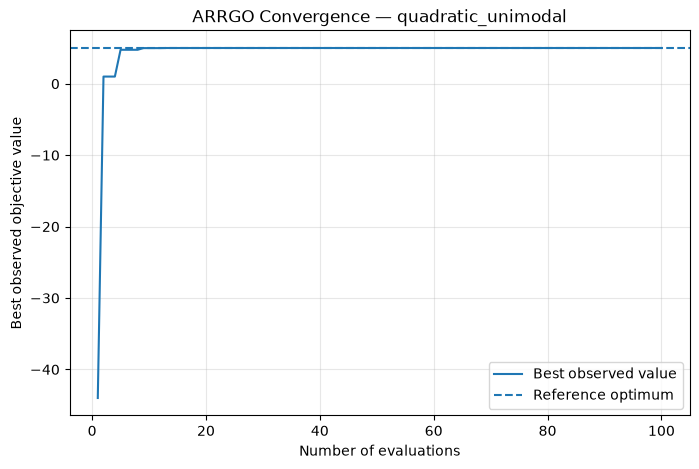

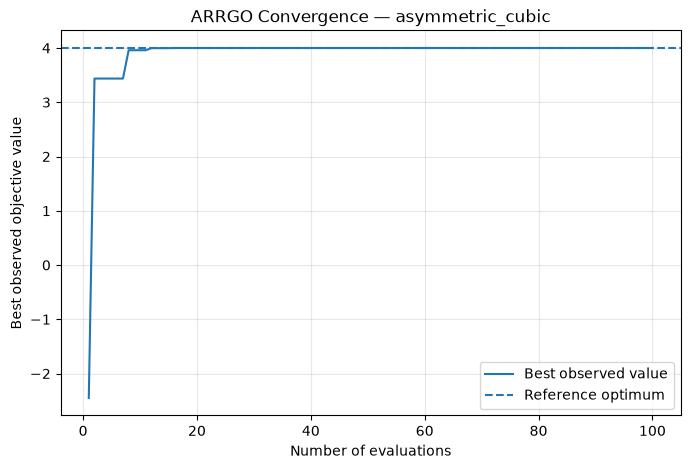

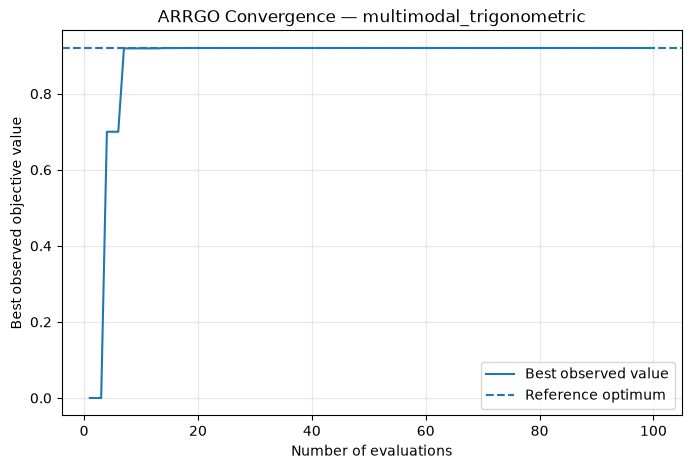

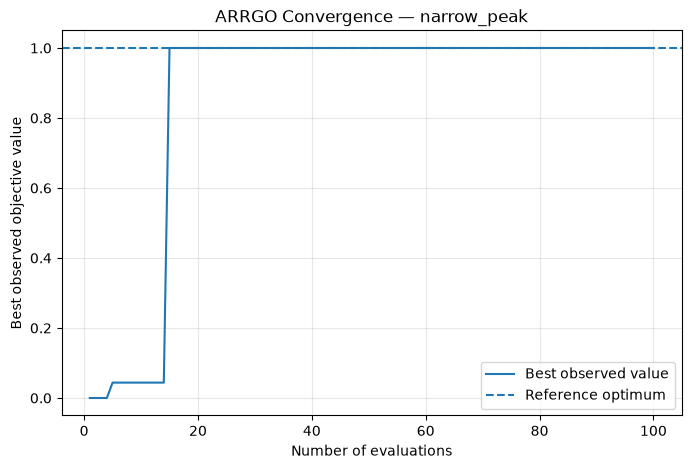

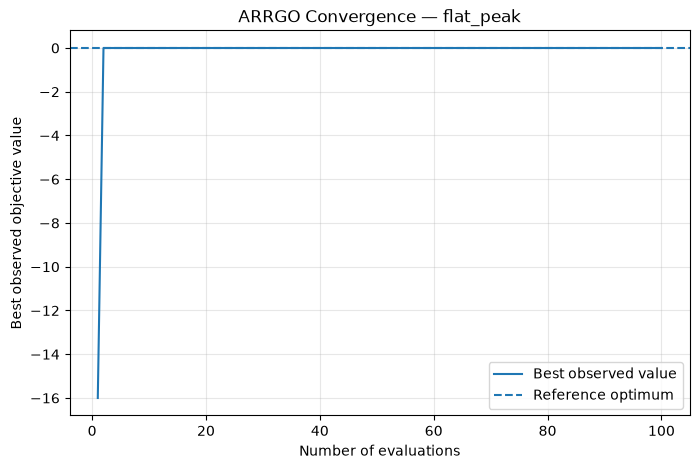

In [61]:
import matplotlib.pyplot as plt


for benchmark in BENCHMARKS:
    name = benchmark.name
    history = CONVERGENCE_HISTORY[name]

    plt.figure(figsize=(8, 5))

    plt.plot(
        history["evaluation"],
        history["best_value"],
        label="Best observed value",
    )

    plt.axhline(
        benchmark.reference_value,
        linestyle="--",
        label="Reference optimum",
    )

    plt.xlabel("Number of evaluations")
    plt.ylabel("Best observed objective value")
    plt.title(f"ARRGO Convergence — {name}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [62]:
for benchmark in BENCHMARKS:
    result = EXPERIMENTAL_RESULTS[benchmark.name]

    state = result.state
    history = state.evaluation_history
    hierarchy = state.region_hierarchy

    print(f"\n{benchmark.name}")
    print("-" * len(benchmark.name))
    print(f"Evaluations: {history.count}")
    print(f"Regions: {len(hierarchy.regions)}")


quadratic_unimodal
------------------
Evaluations: 100
Regions: 199

asymmetric_cubic
----------------
Evaluations: 100
Regions: 187

multimodal_trigonometric
------------------------
Evaluations: 100
Regions: 189

narrow_peak
-----------
Evaluations: 100
Regions: 23

flat_peak
---------
Evaluations: 100
Regions: 197


In [63]:
for benchmark in BENCHMARKS:
    result = EXPERIMENTAL_RESULTS[benchmark.name]
    regions = result.state.region_hierarchy.regions

    state_counts = {}

    for region in regions:
        state_name = region.state.value
        state_counts[state_name] = state_counts.get(state_name, 0) + 1

    print(f"\n{benchmark.name}")
    print("-" * len(benchmark.name))

    for state_name, count in sorted(state_counts.items()):
        print(f"{state_name}: {count}")


quadratic_unimodal
------------------
active: 66
refined: 99
stable: 34

asymmetric_cubic
----------------
active: 57
refined: 93
stable: 37

multimodal_trigonometric
------------------------
active: 63
refined: 94
stable: 32

narrow_peak
-----------
active: 12
refined: 11

flat_peak
---------
active: 71
refined: 98
stable: 28


In [64]:
for benchmark in BENCHMARKS:
    result = EXPERIMENTAL_RESULTS[benchmark.name]

    evaluation_count = result.state.evaluation_history.count
    region_count = len(result.state.region_hierarchy.regions)

    split_count = (region_count - 1) // 2

    print(f"\n{benchmark.name}")
    print("-" * len(benchmark.name))
    print(f"Evaluations: {evaluation_count}")
    print(f"Regions: {region_count}")
    print(f"Estimated splits: {split_count}")


quadratic_unimodal
------------------
Evaluations: 100
Regions: 199
Estimated splits: 99

asymmetric_cubic
----------------
Evaluations: 100
Regions: 187
Estimated splits: 93

multimodal_trigonometric
------------------------
Evaluations: 100
Regions: 189
Estimated splits: 94

narrow_peak
-----------
Evaluations: 100
Regions: 23
Estimated splits: 11

flat_peak
---------
Evaluations: 100
Regions: 197
Estimated splits: 98


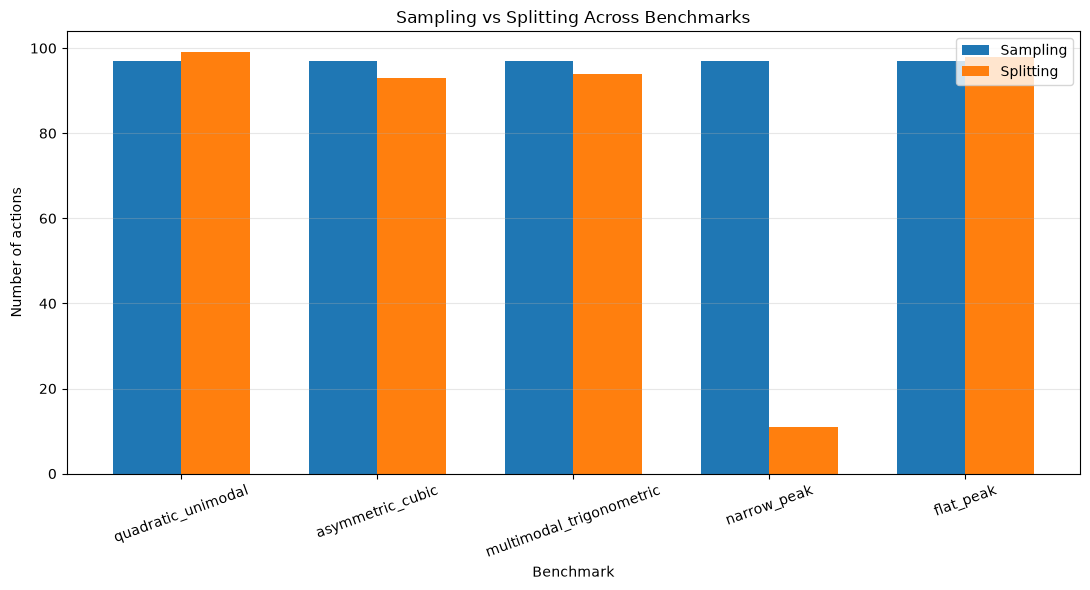

In [65]:
import matplotlib.pyplot as plt
import numpy as np


INITIAL_SAMPLING_COUNT = 3

benchmark_names = []
sampling_counts = []
split_counts = []

for benchmark in BENCHMARKS:
    result = EXPERIMENTAL_RESULTS[benchmark.name]

    evaluation_count = result.state.evaluation_history.count
    region_count = len(result.state.region_hierarchy.regions)

    sampling_count = evaluation_count - INITIAL_SAMPLING_COUNT
    split_count = (region_count - 1) // 2

    benchmark_names.append(benchmark.name)
    sampling_counts.append(sampling_count)
    split_counts.append(split_count)


x = np.arange(len(benchmark_names))
width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - width / 2,
    sampling_counts,
    width,
    label="Sampling",
)

plt.bar(
    x + width / 2,
    split_counts,
    width,
    label="Splitting",
)

plt.xlabel("Benchmark")
plt.ylabel("Number of actions")
plt.title("Sampling vs Splitting Across Benchmarks")
plt.xticks(x, benchmark_names, rotation=20)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [66]:
CONVERGENCE_TOLERANCE = 1e-8

for benchmark in BENCHMARKS:
    history = CONVERGENCE_HISTORY[benchmark.name]

    final_best = history["best_value"][-1]

    convergence_evaluation = None

    for evaluation, best_value in zip(
        history["evaluation"],
        history["best_value"],
    ):
        if abs(final_best - best_value) <= CONVERGENCE_TOLERANCE:
            convergence_evaluation = evaluation
            break

    print(
        f"{benchmark.name}: "
        f"final_best={final_best:.10f}, "
        f"first_final_value_at_evaluation={convergence_evaluation}"
    )

quadratic_unimodal: final_best=4.9999394890, first_final_value_at_evaluation=19
asymmetric_cubic: final_best=3.9999903137, first_final_value_at_evaluation=22
multimodal_trigonometric: final_best=0.9202119614, first_final_value_at_evaluation=18
narrow_peak: final_best=1.0000000000, first_final_value_at_evaluation=15
flat_peak: final_best=-0.0000000000, first_final_value_at_evaluation=2


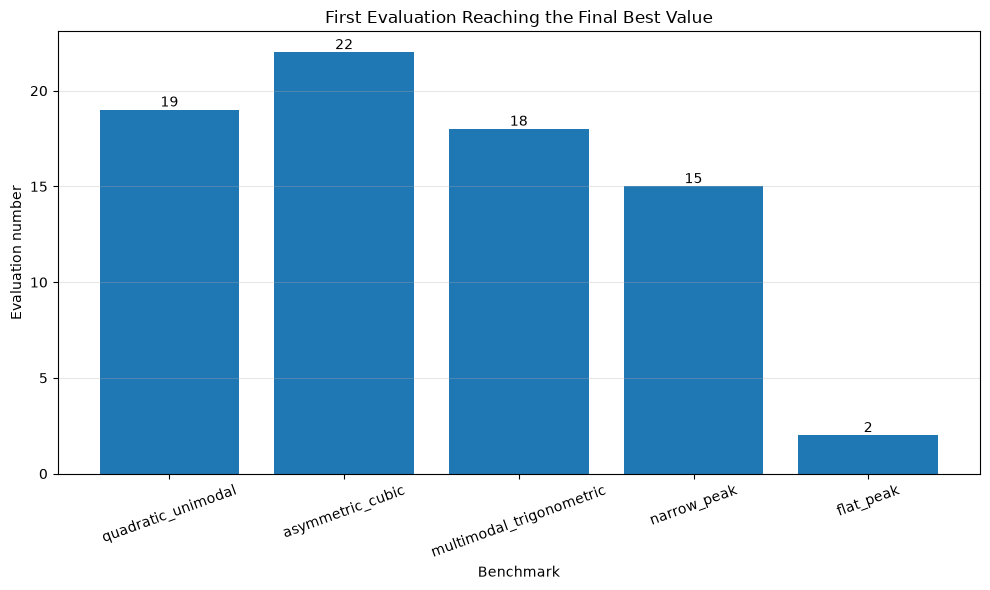

In [67]:
convergence_evaluations = []

for benchmark in BENCHMARKS:
    history = CONVERGENCE_HISTORY[benchmark.name]
    final_best = history["best_value"][-1]

    convergence_evaluation = None

    for evaluation, best_value in zip(
        history["evaluation"],
        history["best_value"],
    ):
        if abs(final_best - best_value) <= CONVERGENCE_TOLERANCE:
            convergence_evaluation = evaluation
            break

    convergence_evaluations.append(convergence_evaluation)


plt.figure(figsize=(10, 6))

bars = plt.bar(
    benchmark_names,
    convergence_evaluations,
)

plt.xlabel("Benchmark")
plt.ylabel("Evaluation number")
plt.title("First Evaluation Reaching the Final Best Value")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, convergence_evaluations):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        str(value),
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

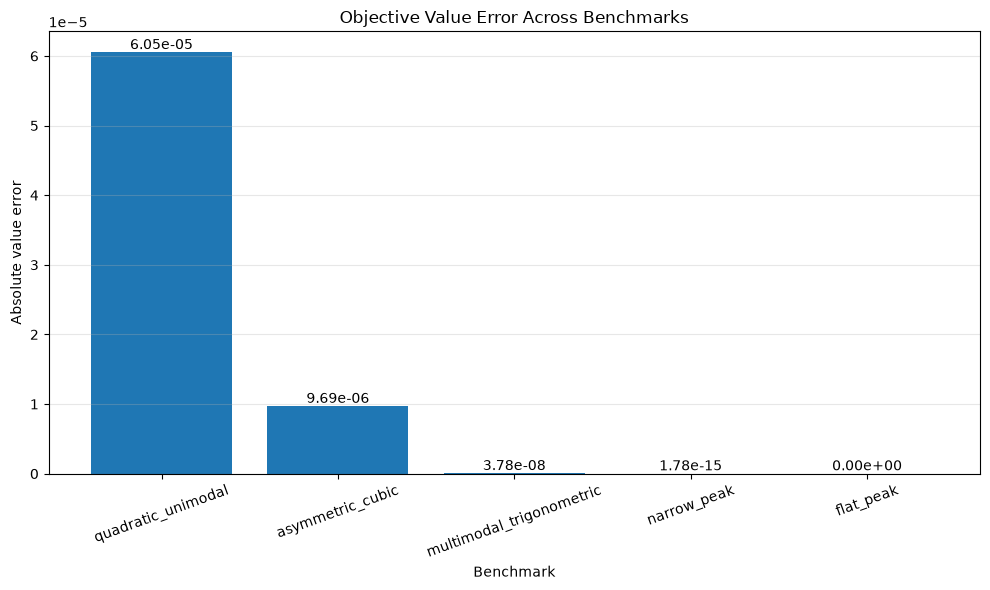

In [68]:
value_errors = []

for benchmark in BENCHMARKS:
    result = EXPERIMENTAL_RESULTS[benchmark.name]

    value_error = abs(
        benchmark.reference_value - result.best_value
    )

    value_errors.append(value_error)


plt.figure(figsize=(10, 6))

bars = plt.bar(
    benchmark_names,
    value_errors,
)

plt.xlabel("Benchmark")
plt.ylabel("Absolute value error")
plt.title("Objective Value Error Across Benchmarks")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, value_errors):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2e}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

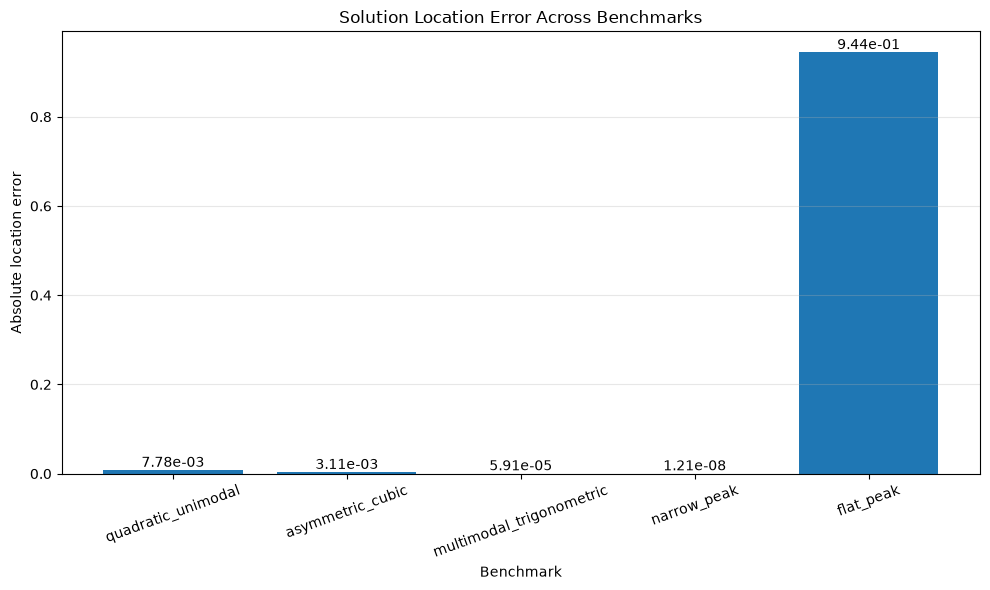

In [69]:
location_errors = []

for benchmark in BENCHMARKS:
    result = EXPERIMENTAL_RESULTS[benchmark.name]

    location_error = abs(
        benchmark.reference_x - result.best_x
    )

    location_errors.append(location_error)


plt.figure(figsize=(10, 6))

bars = plt.bar(
    benchmark_names,
    location_errors,
)

plt.xlabel("Benchmark")
plt.ylabel("Absolute location error")
plt.title("Solution Location Error Across Benchmarks")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, location_errors):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2e}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

In [71]:
LOCATION_TOLERANCE = 1e-2

OPTIMAL_LOCATION_INTERVALS = {
    "quadratic_unimodal": (2.0, 2.0),
    "asymmetric_cubic": (0.8, 0.8),
    "multimodal_trigonometric": (
        REFERENCE_OPTIMA["multimodal_trigonometric"]["x"],
        REFERENCE_OPTIMA["multimodal_trigonometric"]["x"],
    ),
    "narrow_peak": (
        REFERENCE_OPTIMA["narrow_peak"]["x"],
        REFERENCE_OPTIMA["narrow_peak"]["x"],
    ),
    "flat_peak": (0.0, 2.0),
}


for benchmark in BENCHMARKS:
    result = EXPERIMENTAL_RESULTS[benchmark.name]

    lower_optimum, upper_optimum = OPTIMAL_LOCATION_INTERVALS[
        benchmark.name
    ]

    if lower_optimum == upper_optimum:
        is_optimal_location = (
            abs(result.best_x - lower_optimum)
            <= LOCATION_TOLERANCE
        )
    else:
        is_optimal_location = (
            lower_optimum
            <= result.best_x
            <= upper_optimum
        )

    print(
        f"{benchmark.name}: "
        f"best_x={result.best_x:.10f}, "
        f"optimal_location={is_optimal_location}"
    )

quadratic_unimodal: best_x=2.0077788830, optimal_location=True
asymmetric_cubic: best_x=0.8031115532, optimal_location=True
multimodal_trigonometric: best_x=0.7760758386, optimal_location=True
narrow_peak: best_x=1.5000000000, optimal_location=True
flat_peak: best_x=0.0000000000, optimal_location=True


In [72]:
FINAL_EXPERIMENTAL_SUMMARY = []

for benchmark in BENCHMARKS:
    result = EXPERIMENTAL_RESULTS[benchmark.name]

    final_best_value = result.best_value
    reference_value = benchmark.reference_value

    value_error = abs(
        reference_value - final_best_value
    )

    location_error = abs(
        benchmark.reference_x - result.best_x
    )

    history = CONVERGENCE_HISTORY[benchmark.name]

    convergence_evaluation = None

    for evaluation, best_value in zip(
        history["evaluation"],
        history["best_value"],
    ):
        if abs(
            history["best_value"][-1] - best_value
        ) <= CONVERGENCE_TOLERANCE:
            convergence_evaluation = evaluation
            break

    region_count = len(
        result.state.region_hierarchy.regions
    )

    split_count = (region_count - 1) // 2

    sampling_count = (
        result.evaluation_count
        - INITIAL_SAMPLING_COUNT
    )

    lower_optimum, upper_optimum = (
        OPTIMAL_LOCATION_INTERVALS[benchmark.name]
    )

    if lower_optimum == upper_optimum:
        optimal_location = (
            abs(result.best_x - lower_optimum)
            <= LOCATION_TOLERANCE
        )
    else:
        optimal_location = (
            lower_optimum
            <= result.best_x
            <= upper_optimum
        )

    FINAL_EXPERIMENTAL_SUMMARY.append(
        {
            "benchmark": benchmark.name,
            "best_x": result.best_x,
            "best_value": final_best_value,
            "reference_value": reference_value,
            "value_error": value_error,
            "location_error": location_error,
            "optimal_location": optimal_location,
            "convergence_evaluation": convergence_evaluation,
            "sampling_count": sampling_count,
            "split_count": split_count,
            "region_count": region_count,
            "evaluation_count": result.evaluation_count,
            "termination": result.termination_reason.value,
        }
    )


FINAL_EXPERIMENTAL_SUMMARY_DF = pd.DataFrame(
    FINAL_EXPERIMENTAL_SUMMARY
)

FINAL_EXPERIMENTAL_SUMMARY_DF

,benchmark,best_x,best_value,reference_value,value_error,location_error,optimal_location,convergence_evaluation,sampling_count,split_count,region_count,evaluation_count,termination
0,quadratic_unimodal,2.007779,4.999939,5.000000,6.051102e-05,7.778883e-03,True,19,97,99,199,100,budget_exhausted
1,asymmetric_cubic,0.803112,3.999990,4.000000,9.686281e-06,3.110771e-03,True,22,97,93,187,100,budget_exhausted
2,multimodal_trigonometric,0.776076,0.920212,0.920212,3.776176e-08,5.910740e-05,True,18,97,94,189,100,budget_exhausted
3,narrow_peak,1.500000,1.000000,1.000000,1.776357e-15,1.209932e-08,True,15,97,11,23,100,budget_exhausted
4,flat_peak,0.000000,-0.000000,-0.000000,0.000000e+00,9.442755e-01,True,2,97,98,197,100,budget_exhausted


In [74]:
for benchmark in BENCHMARKS:
    history = CONVERGENCE_HISTORY[benchmark.name]["best_value"]

    is_monotonic = all(
        current >= previous
        for previous, current in zip(history, history[1:])
    )

    print(
        f"{benchmark.name}: "
        f"best_value_monotonic={is_monotonic}"
    )

quadratic_unimodal: best_value_monotonic=True
asymmetric_cubic: best_value_monotonic=True
multimodal_trigonometric: best_value_monotonic=True
narrow_peak: best_value_monotonic=True
flat_peak: best_value_monotonic=True


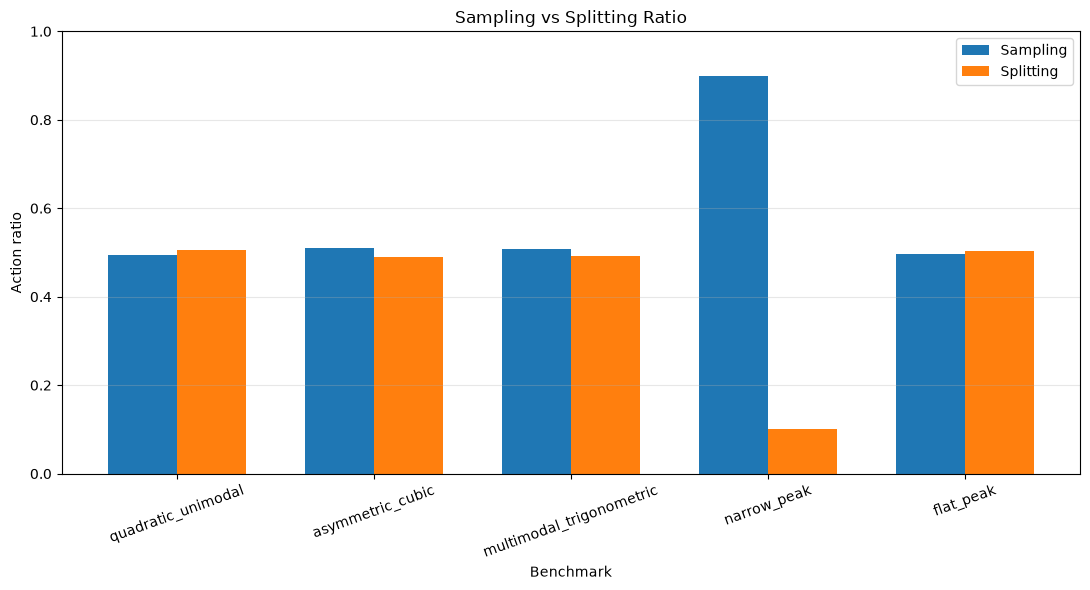

In [75]:
sampling_ratios = []
splitting_ratios = []

for benchmark in BENCHMARKS:
    result = EXPERIMENTAL_RESULTS[benchmark.name]

    sampling_count = (
        result.evaluation_count
        - INITIAL_SAMPLING_COUNT
    )

    region_count = len(
        result.state.region_hierarchy.regions
    )

    split_count = (region_count - 1) // 2

    total_actions = sampling_count + split_count

    sampling_ratio = sampling_count / total_actions
    splitting_ratio = split_count / total_actions

    sampling_ratios.append(sampling_ratio)
    splitting_ratios.append(splitting_ratio)


x = np.arange(len(benchmark_names))
width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - width / 2,
    sampling_ratios,
    width,
    label="Sampling",
)

plt.bar(
    x + width / 2,
    splitting_ratios,
    width,
    label="Splitting",
)

plt.xlabel("Benchmark")
plt.ylabel("Action ratio")
plt.title("Sampling vs Splitting Ratio")
plt.xticks(x, benchmark_names, rotation=20)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

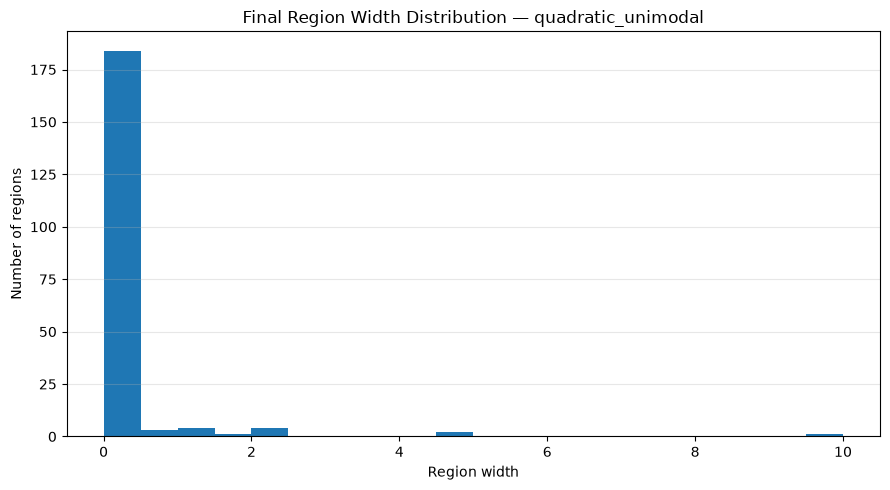

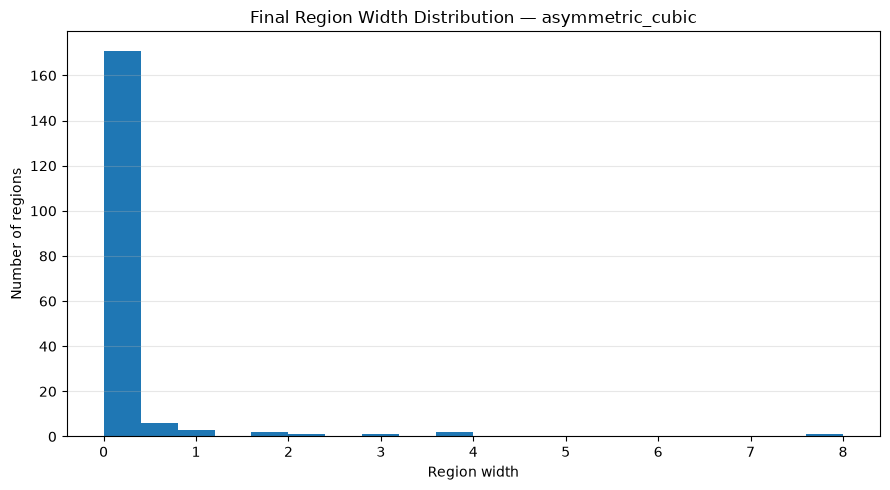

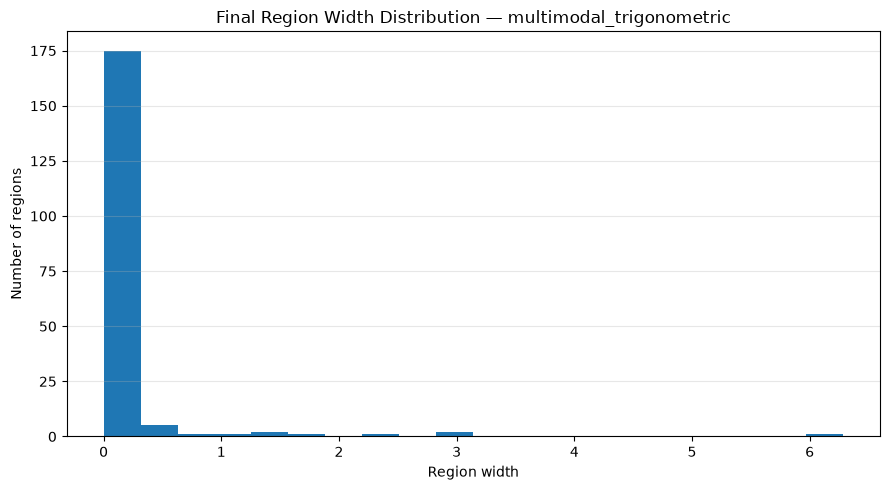

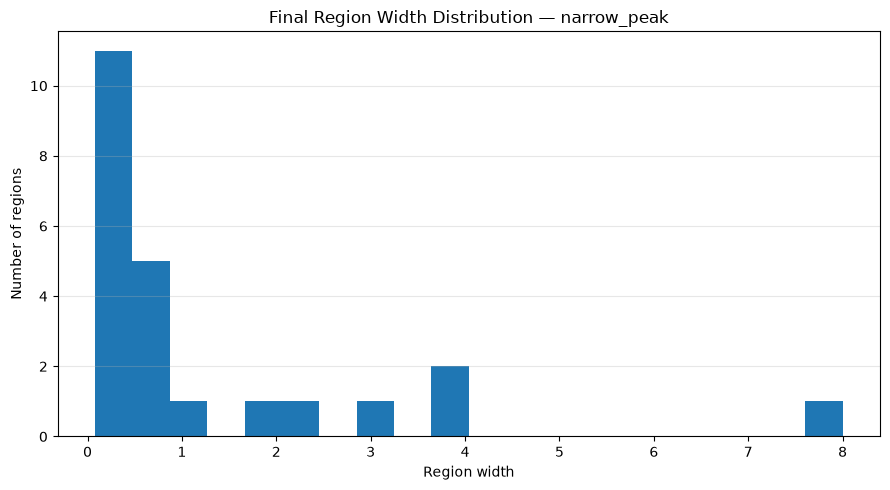

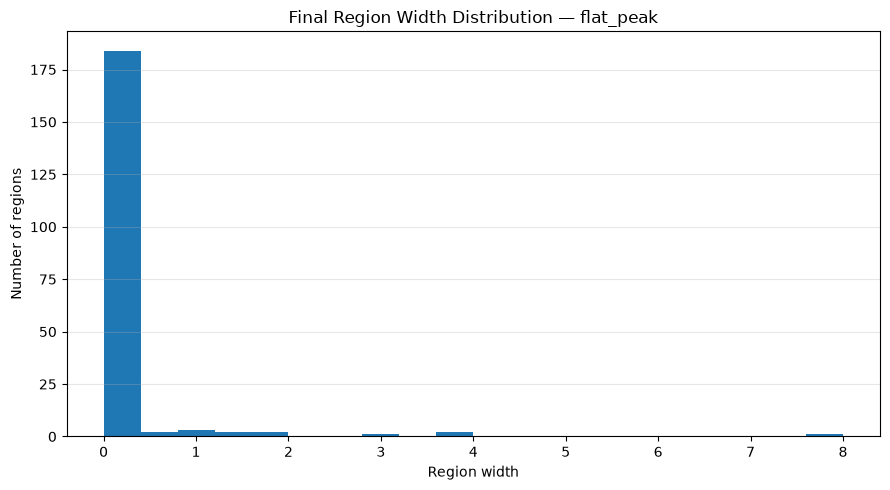

In [76]:
for benchmark in BENCHMARKS:
    regions = (
        EXPERIMENTAL_RESULTS[benchmark.name]
        .state
        .region_hierarchy
        .regions
    )

    region_widths = [
        region.right_x - region.left_x
        for region in regions
    ]

    plt.figure(figsize=(9, 5))

    plt.hist(
        region_widths,
        bins=20,
    )

    plt.xlabel("Region width")
    plt.ylabel("Number of regions")
    plt.title(
        f"Final Region Width Distribution — {benchmark.name}"
    )
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

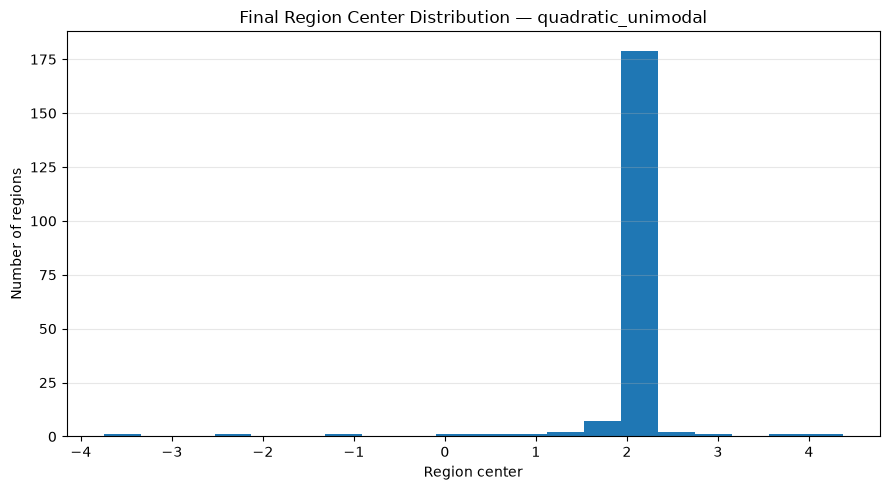

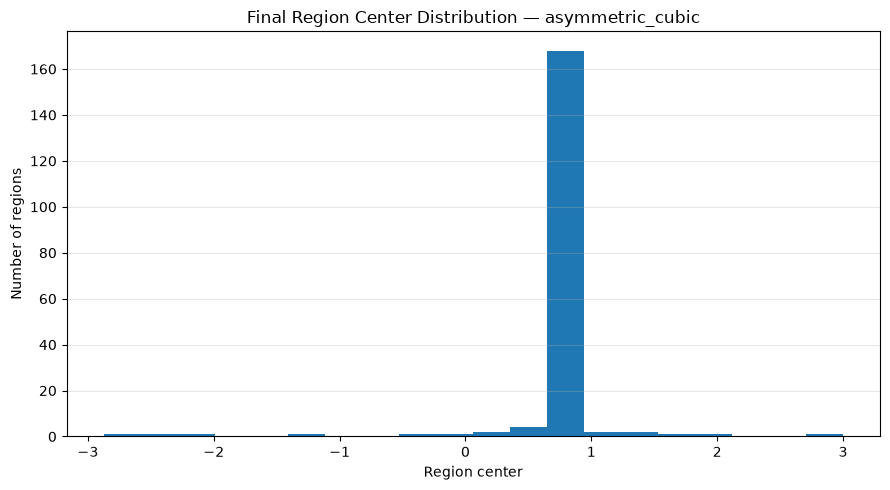

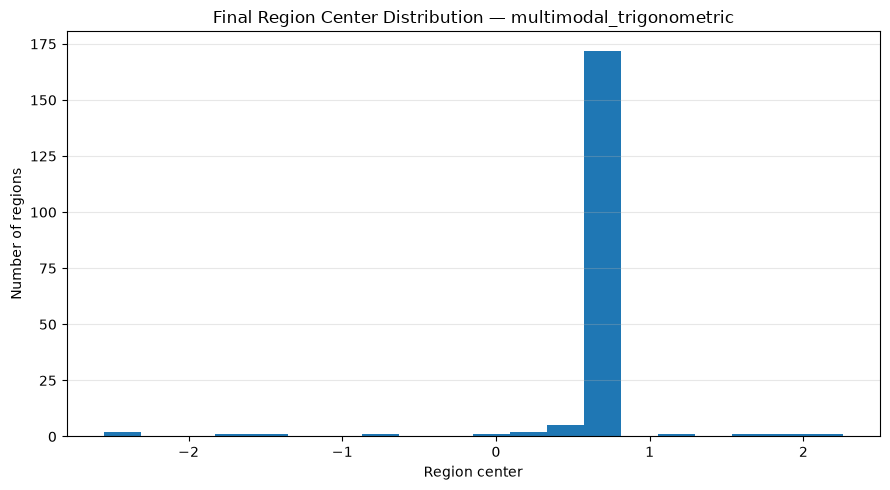

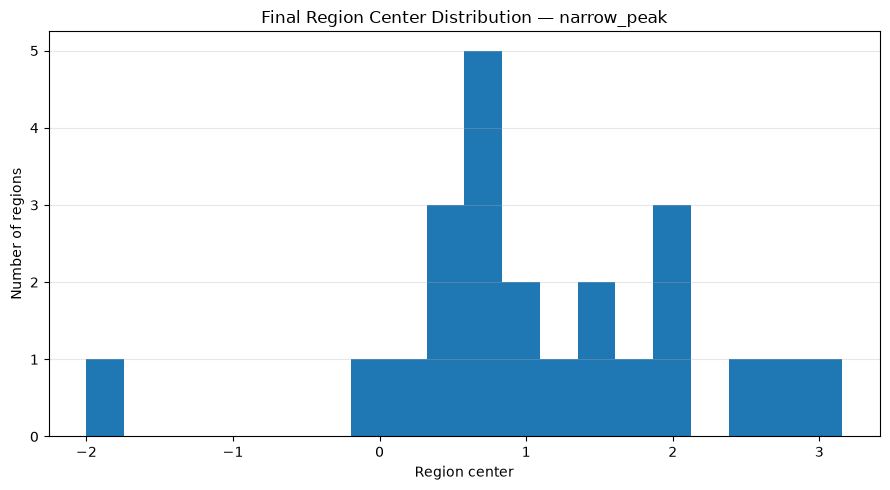

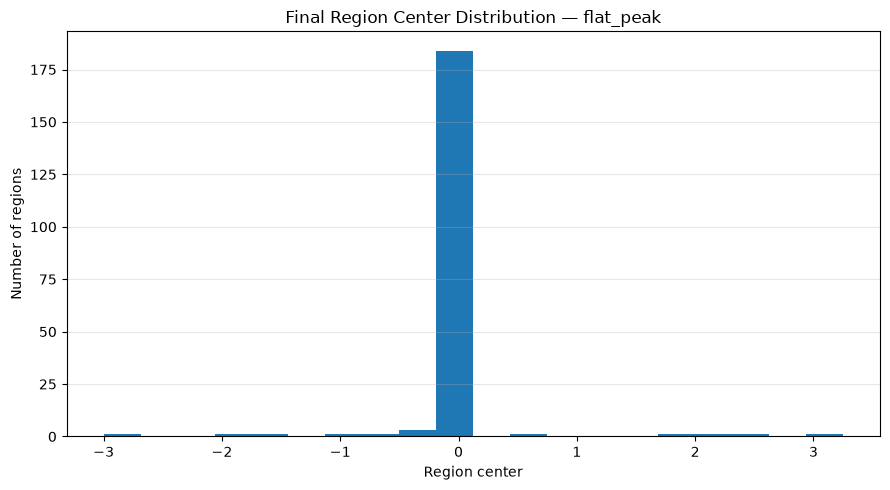

In [77]:
for benchmark in BENCHMARKS:
    regions = (
        EXPERIMENTAL_RESULTS[benchmark.name]
        .state
        .region_hierarchy
        .regions
    )

    region_centers = [
        (region.left_x + region.right_x) / 2.0
        for region in regions
    ]

    plt.figure(figsize=(9, 5))

    plt.hist(
        region_centers,
        bins=20,
    )

    plt.xlabel("Region center")
    plt.ylabel("Number of regions")
    plt.title(
        f"Final Region Center Distribution — {benchmark.name}"
    )
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

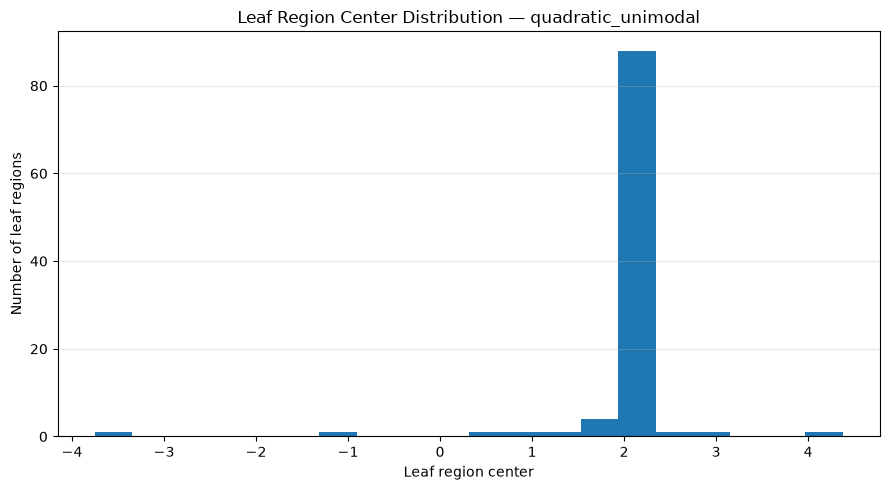

quadratic_unimodal: leaf_regions=100


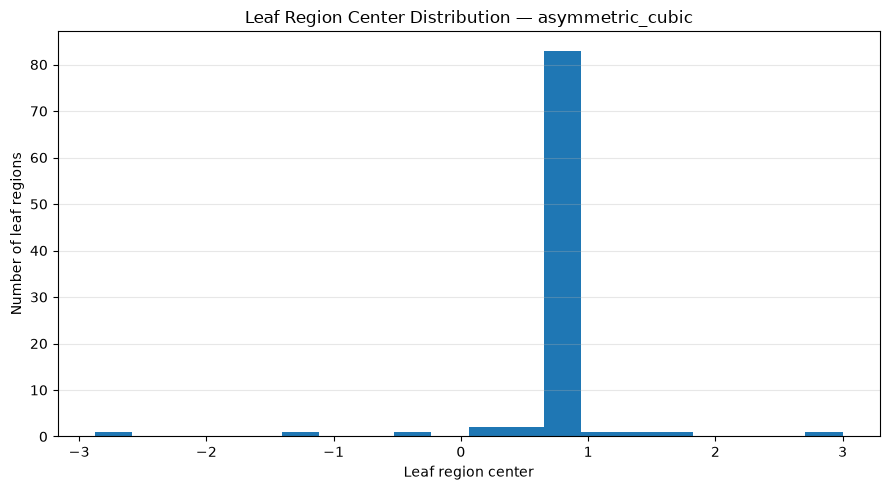

asymmetric_cubic: leaf_regions=94


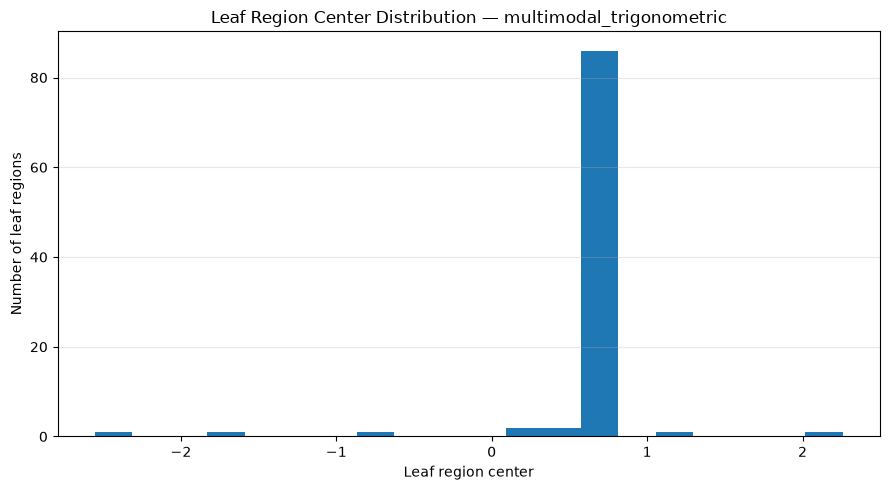

multimodal_trigonometric: leaf_regions=95


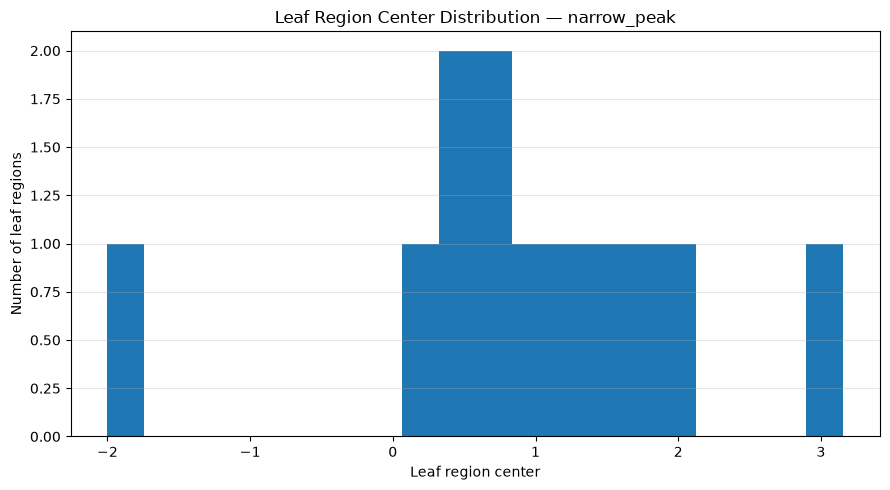

narrow_peak: leaf_regions=12


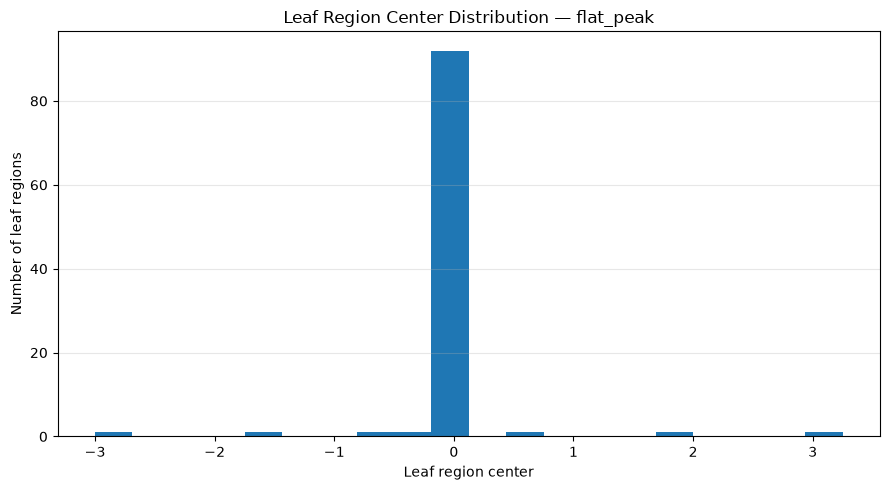

flat_peak: leaf_regions=99


In [78]:
for benchmark in BENCHMARKS:
    regions = (
        EXPERIMENTAL_RESULTS[benchmark.name]
        .state
        .region_hierarchy
        .regions
    )

    leaf_regions = [
        region
        for region in regions
        if not region.children_ids
    ]

    leaf_centers = [
        (region.left_x + region.right_x) / 2.0
        for region in leaf_regions
    ]

    plt.figure(figsize=(9, 5))

    plt.hist(
        leaf_centers,
        bins=20,
    )

    plt.xlabel("Leaf region center")
    plt.ylabel("Number of leaf regions")
    plt.title(
        f"Leaf Region Center Distribution — {benchmark.name}"
    )
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(
        f"{benchmark.name}: "
        f"leaf_regions={len(leaf_regions)}"
    )

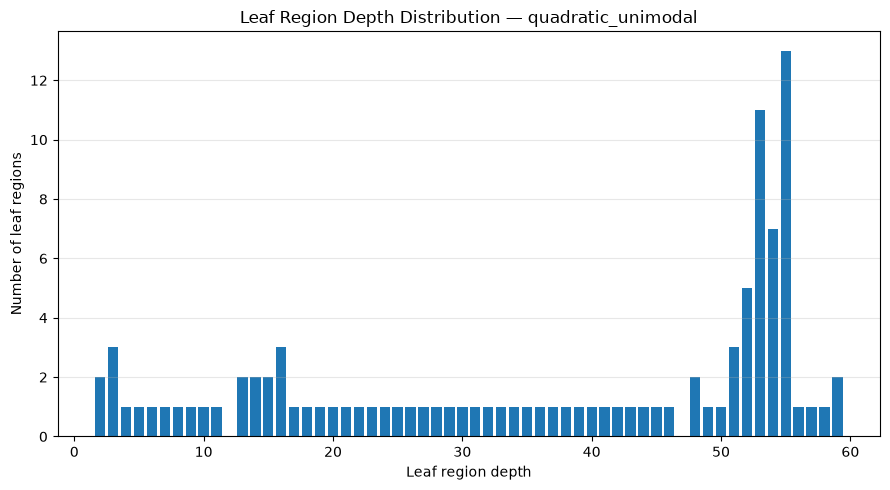

quadratic_unimodal: min_depth=2, max_depth=59, leaf_regions=100


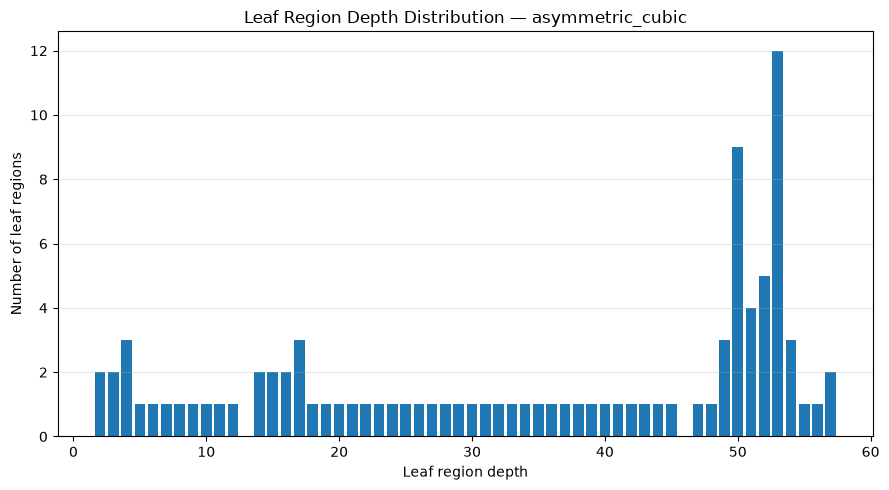

asymmetric_cubic: min_depth=2, max_depth=57, leaf_regions=94


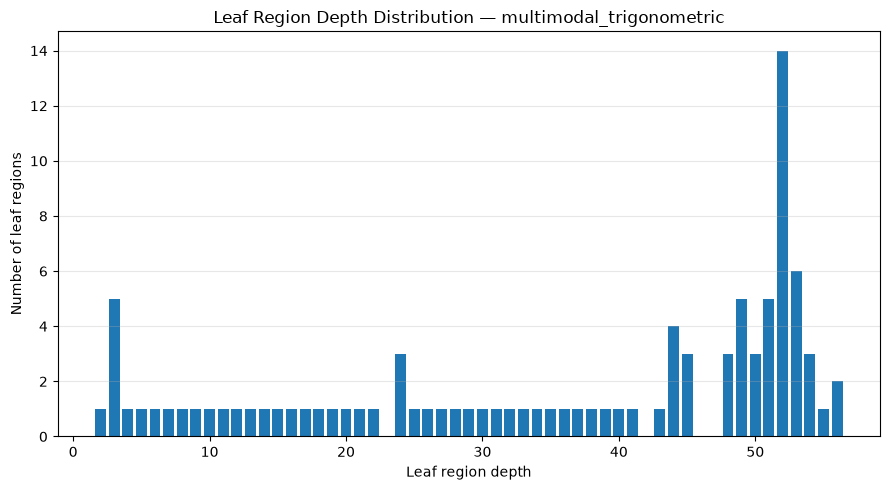

multimodal_trigonometric: min_depth=2, max_depth=56, leaf_regions=95


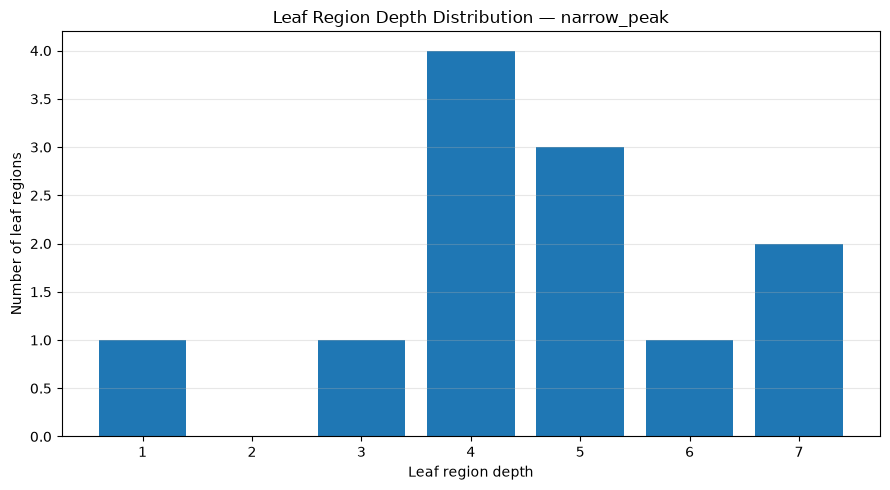

narrow_peak: min_depth=1, max_depth=7, leaf_regions=12


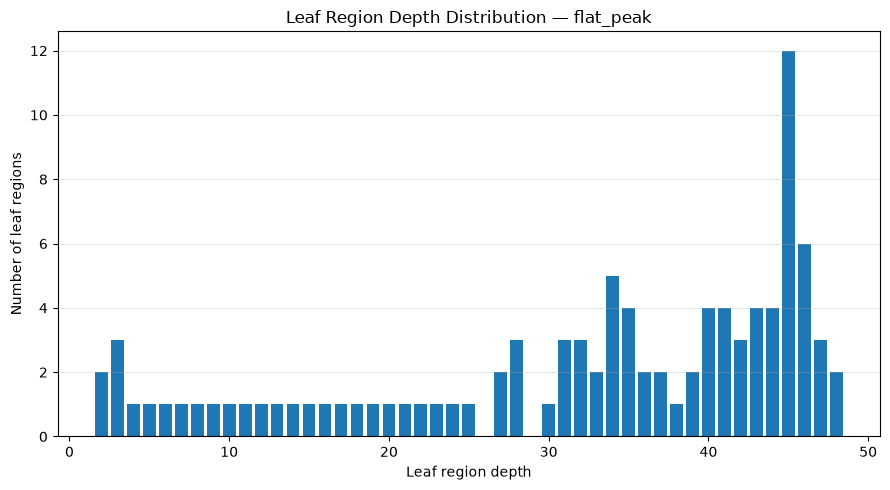

flat_peak: min_depth=2, max_depth=48, leaf_regions=99


In [79]:
for benchmark in BENCHMARKS:
    regions = (
        EXPERIMENTAL_RESULTS[benchmark.name]
        .state
        .region_hierarchy
        .regions
    )

    region_by_id = {
        region.id: region
        for region in regions
    }

    leaf_regions = [
        region
        for region in regions
        if not region.children_ids
    ]

    leaf_depths = []

    for region in leaf_regions:
        depth = 0
        current = region

        while current.parent_id is not None:
            depth += 1
            current = region_by_id[current.parent_id]

        leaf_depths.append(depth)

    plt.figure(figsize=(9, 5))

    plt.hist(
        leaf_depths,
        bins=range(
            min(leaf_depths),
            max(leaf_depths) + 2,
        ),
        align="left",
        rwidth=0.8,
    )

    plt.xlabel("Leaf region depth")
    plt.ylabel("Number of leaf regions")
    plt.title(
        f"Leaf Region Depth Distribution — {benchmark.name}"
    )
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(
        f"{benchmark.name}: "
        f"min_depth={min(leaf_depths)}, "
        f"max_depth={max(leaf_depths)}, "
        f"leaf_regions={len(leaf_regions)}"
    )

In [80]:
for benchmark in BENCHMARKS:
    regions = (
        EXPERIMENTAL_RESULTS[benchmark.name]
        .state
        .region_hierarchy
        .regions
    )

    region_by_id = {
        region.id: region
        for region in regions
    }

    leaf_regions = [
        region
        for region in regions
        if not region.children_ids
    ]

    leaf_depths = []

    for region in leaf_regions:
        depth = 0
        current = region

        while current.parent_id is not None:
            depth += 1
            current = region_by_id[current.parent_id]

        leaf_depths.append(depth)

    print(
        f"{benchmark.name}: "
        f"mean_depth={np.mean(leaf_depths):.2f}, "
        f"max_depth={max(leaf_depths)}, "
        f"min_depth={min(leaf_depths)}"
    )

quadratic_unimodal: mean_depth=37.23, max_depth=59, min_depth=2
asymmetric_cubic: mean_depth=35.02, max_depth=57, min_depth=2
multimodal_trigonometric: mean_depth=36.00, max_depth=56, min_depth=2
narrow_peak: mean_depth=4.58, max_depth=7, min_depth=1
flat_peak: mean_depth=32.10, max_depth=48, min_depth=2


In [81]:
benchmark = next(
    benchmark
    for benchmark in BENCHMARKS
    if benchmark.name == "narrow_peak"
)

result = EXPERIMENTAL_RESULTS[benchmark.name]

regions = result.state.region_hierarchy.regions

state_counts = {}

for region in regions:
    state_name = region.state.value
    state_counts[state_name] = (
        state_counts.get(state_name, 0) + 1
    )

print("Narrow Peak final region states:")

for state_name, count in sorted(state_counts.items()):
    print(f"{state_name}: {count}")

print(f"\nTotal regions: {len(regions)}")
print(f"Evaluations: {result.evaluation_count}")
print(f"Termination: {result.termination_reason.value}")

Narrow Peak final region states:
active: 12
refined: 11

Total regions: 23
Evaluations: 100
Termination: budget_exhausted


In [82]:
for benchmark in BENCHMARKS:
    result = EXPERIMENTAL_RESULTS[benchmark.name]

    region_count = len(
        result.state.region_hierarchy.regions
    )

    split_count = (region_count - 1) // 2

    sampling_count = (
        result.evaluation_count
        - INITIAL_SAMPLING_COUNT
    )

    split_ratio = split_count / (
        sampling_count + split_count
    )

    print(
        f"{benchmark.name}: "
        f"sampling={sampling_count}, "
        f"split={split_count}, "
        f"split_ratio={split_ratio:.3f}"
    )

quadratic_unimodal: sampling=97, split=99, split_ratio=0.505
asymmetric_cubic: sampling=97, split=93, split_ratio=0.489
multimodal_trigonometric: sampling=97, split=94, split_ratio=0.492
narrow_peak: sampling=97, split=11, split_ratio=0.102
flat_peak: sampling=97, split=98, split_ratio=0.503


In [83]:
benchmark = next(
    benchmark
    for benchmark in BENCHMARKS
    if benchmark.name == "narrow_peak"
)

config = EXPERIMENT_CONFIGS[benchmark.name]

repeat_result = run_arrgo(
    objective=benchmark.function,
    config=config,
)

original_result = EXPERIMENTAL_RESULTS[benchmark.name]

print("Original run:")
print(f"best_x={original_result.best_x:.10f}")
print(f"best_value={original_result.best_value:.10f}")
print(f"evaluations={original_result.evaluation_count}")
print(f"regions={len(original_result.state.region_hierarchy.regions)}")

print("\nRepeated run:")
print(f"best_x={repeat_result.best_x:.10f}")
print(f"best_value={repeat_result.best_value:.10f}")
print(f"evaluations={repeat_result.evaluation_count}")
print(f"regions={len(repeat_result.state.region_hierarchy.regions)}")

print("\nDeterministic behavior:")

print(
    original_result.best_x == repeat_result.best_x
    and original_result.best_value == repeat_result.best_value
    and len(original_result.state.region_hierarchy.regions)
    == len(repeat_result.state.region_hierarchy.regions)
)

Original run:
best_x=1.5000000000
best_value=1.0000000000
evaluations=100
regions=23

Repeated run:
best_x=1.5000000000
best_value=1.0000000000
evaluations=100
regions=23

Deterministic behavior:
True


## 6. Experimental Findings

The experimental results reveal several consistent behavioral patterns in ARRGO across the selected benchmark functions.

### 6.1 Optimization Accuracy

ARRGO reached objective values very close to the reference optima for all tested benchmarks.

The absolute objective-value errors were small across the experiments:

- Quadratic Unimodal: approximately \(6.05\times10^{-5}\)
- Asymmetric Smooth: approximately \(9.69\times10^{-6}\)
- Multimodal Trigonometric: approximately \(3.78\times10^{-8}\)
- Narrow Peak: approximately \(1.78\times10^{-15}\)
- Flat Peak: \(0\)

The flat-peak benchmark has a non-unique global optimum, so objective-value accuracy is more informative than distance to a single reference location.

### 6.2 Convergence Behavior

The best observed objective value was monotone non-decreasing throughout all tested runs.

In the examined runs, the final best value was reached within the specified convergence tolerance by relatively early evaluations:

- Quadratic Unimodal: evaluation 19
- Asymmetric Smooth: evaluation 22
- Multimodal Trigonometric: evaluation 18
- Narrow Peak: evaluation 15
- Flat Peak: evaluation 2

These values indicate when the final best-found value of the corresponding run was first reached within the selected experimental tolerance. They should not be interpreted as mathematical convergence guarantees.

### 6.3 Spatial Refinement Behavior

The final region hierarchy showed different refinement patterns across the benchmark functions.

Quadratic, Asymmetric Smooth, Multimodal Trigonometric, and Flat Peak produced relatively deep hierarchies, with mean leaf-region depths between approximately 32 and 37.

In contrast, the Narrow Peak benchmark produced a much shallower hierarchy:

$$
\text{mean depth}\approx4.58,
\qquad
\text{maximum depth}=7.
$$

This difference is consistent with the observed structural behavior of ARRGO on the narrow-peak landscape, where substantially fewer splitting operations were performed.

### 6.4 Sampling and Splitting Behavior

The experiments revealed a pronounced difference in the balance between sampling and splitting.

For four benchmarks, the inferred splitting ratio was close to one half:

- Quadratic Unimodal: \(0.505\)
- Asymmetric Smooth: \(0.489\)
- Multimodal Trigonometric: \(0.492\)
- Flat Peak: \(0.503\)

For Narrow Peak, the inferred splitting ratio was substantially lower:

$$
0.102.
$$

Thus, under the tested configuration, ARRGO performed considerably more sampling relative to structural splitting on the Narrow Peak benchmark.

These sampling/splitting counts are derived from the final hierarchy and evaluation budget rather than from an explicit action log. They are therefore treated as descriptive experimental observations rather than primary performance metrics.

### 6.5 Narrow-Peak Behavior

The Narrow Peak benchmark exhibited the most distinct structural behavior.

It produced:

- 100 objective evaluations;
- 23 total regions;
- 11 inferred splitting operations;
- 12 final leaf regions;
- no stable regions at termination;
- a best solution at \(x=1.5\);
- an objective value of \(1.0\).

The same configuration was executed twice and produced identical results for the best location, best objective value, evaluation count, and final region count.

This confirms that the observed Narrow Peak behavior is reproducible under the deterministic experimental configuration.

However, this observation alone does not establish that the behavior represents a universally superior refinement strategy. It only demonstrates a reproducible difference in the algorithm's response to this particular objective landscape.

### 6.6 Interpretation

Overall, the experiments indicate that ARRGO can exhibit different refinement structures depending on the local and global characteristics of the objective function.

The results support the intended design principle that refinement behavior should depend on information extracted from the evaluated regions rather than following a fixed spatial partitioning pattern.

At the same time, these experiments are limited to a small deterministic one-dimensional benchmark set. Therefore, the observed patterns should be considered empirical evidence of the current implementation's behavior rather than universal conclusions about global optimization performance.

## 7. Experimental Limitations

The experimental evaluation provides evidence about the observed behavior of the current ARRGO implementation, but several limitations must be considered when interpreting the results.

### 7.1 Limited Benchmark Set

The experiments use a small collection of deterministic one-dimensional benchmark functions.

Although the selected functions represent different landscape characteristics, they cannot represent the full range of possible global optimization problems.

In particular, higher-dimensional, discontinuous, noisy, constrained, and highly irregular objectives were not evaluated.

### 7.2 Fixed Evaluation Budget

All experiments use a fixed budget of 100 objective evaluations.

This provides a controlled comparison between the selected benchmark functions, but it does not reveal how ARRGO behaves under different computational budgets.

A larger or smaller budget may lead to different refinement structures and solution accuracies.

### 7.3 Empirical Results Are Not Global Optimality Proofs

The empirical experiments measure the best solution found by ARRGO and compare it with numerically verified reference optima.

These comparisons provide evidence of observed optimization behavior, but they do not constitute a universal proof of global optimality.

In Empirical Mode, the final best solution should therefore be interpreted as a best-found solution.

### 7.4 Reference Optima

The benchmark reference optima were obtained numerically using bounded scalar optimization.

They are used as experimental reference values rather than formal analytical proofs of the global optimum.

For the selected smooth benchmark functions, the numerical references are sufficiently accurate for the intended experimental comparisons.

### 7.5 Derived Sampling and Splitting Statistics

The sampling and splitting counts reported in this notebook are derived from the final evaluation count and retained region hierarchy.

They are not obtained from a dedicated action-history log.

Consequently, these statistics are useful for describing the observed structural behavior but should not be treated as exact measurements of the complete temporal decision process.

### 7.6 Hierarchy Representation

ARRGO retains parent regions after splitting.

Therefore, statistics computed over the complete region hierarchy, such as region-center and region-width distributions, include both parent and leaf regions.

Leaf-region statistics reduce this effect, but they still provide only a partial view of the complete refinement process.

### 7.7 Deterministic Reproducibility

The experiments are deterministic under the tested configurations.

This confirms reproducibility for identical objectives and configurations, but it does not imply that the same refinement behavior will occur across different configurations, numerical tolerances, or benchmark families.

### 7.8 Certified Mode Scope

Certified optimization guarantees depend on the validity of the supplied Lipschitz constant.

If the supplied constant is not a valid global bound for the objective over the configured domain, the resulting certificate cannot be considered mathematically valid.

Therefore, certified results must always be interpreted together with their underlying assumptions.

### 7.9 Experimental Scope

The current evaluation is primarily intended to verify consistency between the implementation and the ARRGO design.

It is not intended to establish superiority over existing global optimization algorithms.

A broader comparative study would require additional benchmark families, multiple evaluation budgets, repeated controlled comparisons where appropriate, and established baseline algorithms.

## 8. Final Experimental Summary

The experimental evaluation examined the empirical behavior of ARRGO across five deterministic one-dimensional benchmark functions representing unimodal, asymmetric, multimodal, narrow-peak, and flat-peak landscapes.

Under the tested configuration and a budget of 100 objective evaluations, ARRGO reached objective values very close to the numerically verified reference values for all five benchmarks.

The best observed objective value remained monotone non-decreasing throughout every tested run. The final objective-value errors were small, with the largest observed error occurring on the quadratic benchmark and the smallest errors occurring on the narrow-peak and flat-peak benchmarks.

The experiments also demonstrated that ARRGO does not produce an identical refinement structure for every objective landscape. Four benchmarks generated relatively deep region hierarchies, while the Narrow Peak benchmark produced a substantially shallower hierarchy and considerably fewer splitting operations.

The Narrow Peak behavior was deterministic and reproducible. Repeating the experiment with the same objective and configuration produced identical best solutions, objective values, evaluation counts, and final region counts.

The flat-peak benchmark also demonstrated an important property of the evaluation methodology. Because the objective has multiple global maximizers, the distance between the returned solution and one selected reference point is not by itself a meaningful measure of solution quality. Objective-value accuracy and membership in the optimal region provide a more appropriate interpretation.

Overall, the experiments provide empirical evidence that the current ARRGO implementation:

- reaches high-quality objective values on the selected benchmark functions;
- maintains a monotone best-observed objective value;
- adapts its refinement structure to different objective landscapes;
- exhibits deterministic and reproducible behavior;
- preserves the intended distinction between empirical best-found solutions and certified results;
- remains consistent with the theoretical and algorithmic design established in the previous notebooks.

These findings should be interpreted within the scope of the tested one-dimensional deterministic benchmarks and fixed evaluation budget. They do not establish universal global optimality or superiority over other optimization algorithms.

The experimental results therefore serve as an empirical validation of the current ARRGO design and implementation, while identifying broader benchmark coverage, higher-dimensional evaluation, action-history instrumentation, and comparative algorithmic studies as natural directions for future work.